<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Quantum_Entanglement_Timelines_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

The study of Quantum Entanglement (QE) encompasses a vast spectrum of coherence lifetimes ranging from fleeting femtoseconds in ambient environments to several hours within highly isolated crystalline matrices. It is essential to comprehend the fundamental terms and acronyms that define these physical systems before examining their temporal characteristics.

| Acronym | Complete Definition |
| --- | --- |
| QE | Quantum Entanglement |
| NV | Nitrogen Vacancy |
| SQ | Superconducting Qubit |
| TI | Trapped Ion |
| RP | Radical Pair |

Natural biological mechanisms theorized to utilize RP dynamics exhibit temporary entanglement on the microsecond scale. Synthetic laboratory platforms isolate individual particles in vacuums or cryogenic environments to suppress external decoherence. Systems utilizing NV centers in diamond lattices or meticulously isolated TI configurations can sustain entangled states for exceptionally prolonged periods because they are effectively shielded from thermal fluctuations. This contrasts with SQ circuits which operate at macroscopic scales and typically decohere within fractions of a millisecond.

Using Python 3.12.13 environment at: /usr
Checked 1 package in 80ms


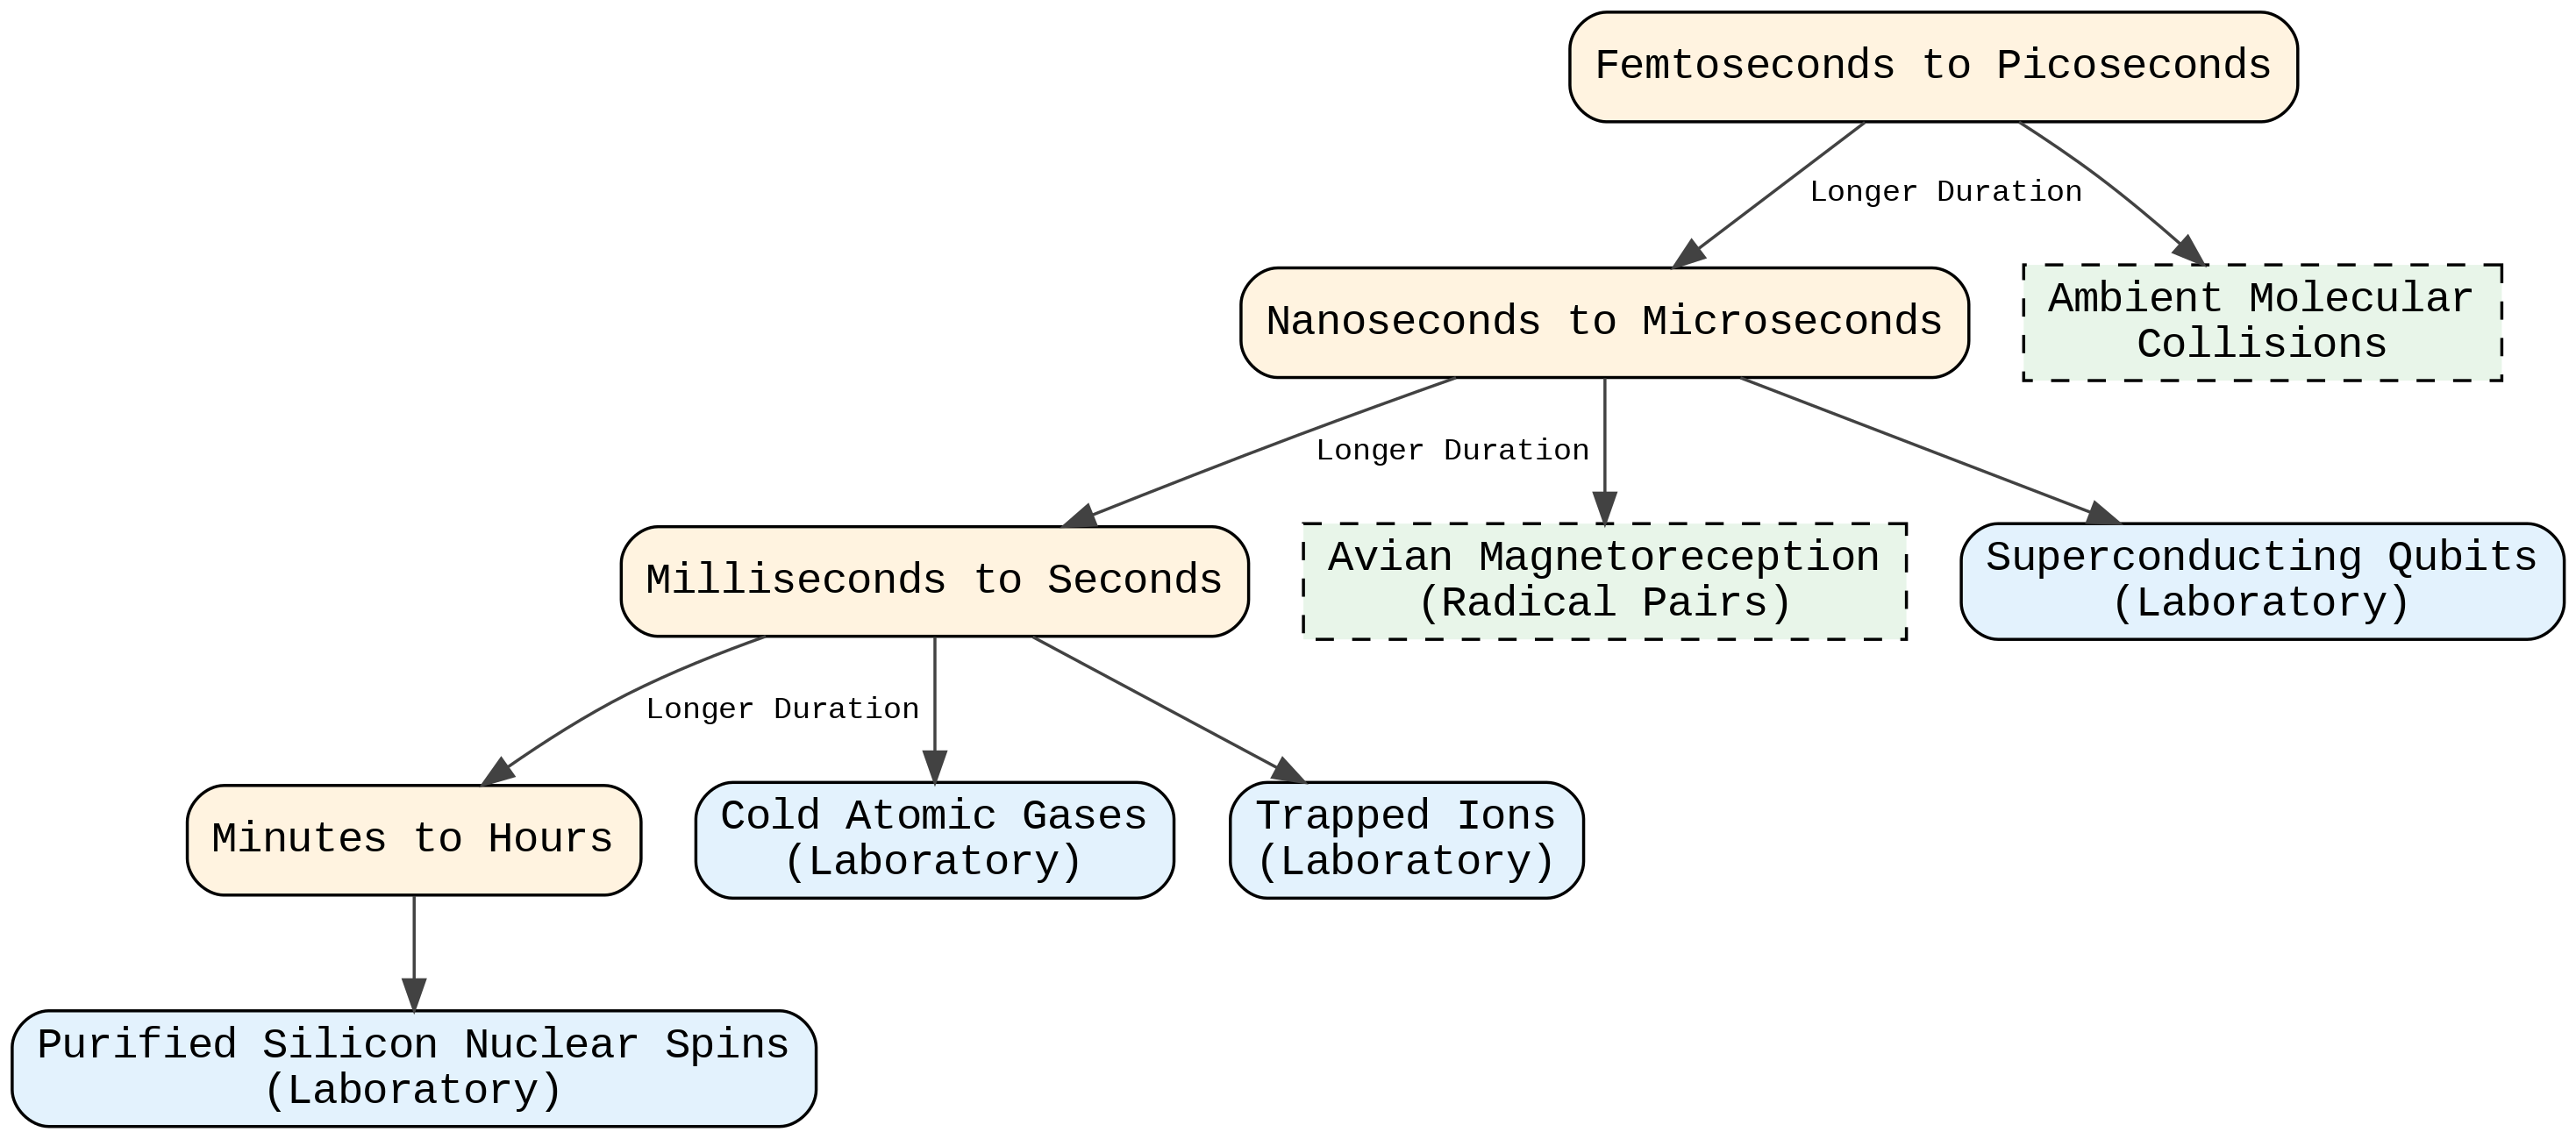

In [ ]:
!pip install uv
!uv pip install graphviz

"""
A Graphviz visualization of quantum entanglement coherence times.

This script generates a directed graph categorizing various quantum
entanglement mechanisms and their associated lifetimes. It distinguishes
between naturally occurring biological phenomena and synthetic systems
engineered within laboratory environments.
"""

import graphviz
from IPython.display import display, Image

# Control Knobs for Graph Configuration
GRAPH_LAYOUT_ENGINE = 'dot'
GRAPH_RANK_DIRECTION = 'TB'
GRAPH_OUTPUT_FORMAT = 'png'
GRAPH_RESOLUTION_DPI = '250'
FONT_NAME = 'Tahoma'

NODE_COLOR_SYNTHETIC = '#e3f2fd'
NODE_COLOR_NATURAL = '#e8f5e9'
NODE_COLOR_TIME = '#fff3e0'

STYLE_FILLED = 'filled, rounded'
STYLE_DASHED = 'filled, dashed'
EDGE_COLOR = '#424242'

def create_entanglement_timeline() -> graphviz.Digraph:
    """
    Constructs a directed graph charting entanglement mechanisms across time scales.

    Returns
        graphviz.Digraph: The compiled graphical timeline ready for rendering.
    """
    timeline_graph = graphviz.Digraph(
        engine=GRAPH_LAYOUT_ENGINE,
        format=GRAPH_OUTPUT_FORMAT,
        graph_attr={
            'rankdir': GRAPH_RANK_DIRECTION,
            'fontname': FONT_NAME,
            'dpi': GRAPH_RESOLUTION_DPI
        }
    )

    timeline_graph.attr('node', fontname=FONT_NAME, shape='box', style=STYLE_FILLED)
    timeline_graph.attr('edge', color=EDGE_COLOR, fontname=FONT_NAME, fontsize='10')

    # Time Scale Nodes
    timeline_graph.node('T1', 'Femtoseconds to Picoseconds', fillcolor=NODE_COLOR_TIME)
    timeline_graph.node('T2', 'Nanoseconds to Microseconds', fillcolor=NODE_COLOR_TIME)
    timeline_graph.node('T3', 'Milliseconds to Seconds', fillcolor=NODE_COLOR_TIME)
    timeline_graph.node('T4', 'Minutes to Hours', fillcolor=NODE_COLOR_TIME)

    # Progression of time
    timeline_graph.edge('T1', 'T2', label=' Longer Duration')
    timeline_graph.edge('T2', 'T3', label=' Longer Duration')
    timeline_graph.edge('T3', 'T4', label=' Longer Duration')

    # Natural Mechanisms
    timeline_graph.node(
        'N1',
        'Avian Magnetoreception\n(Radical Pairs)',
        fillcolor=NODE_COLOR_NATURAL,
        style=STYLE_DASHED
    )
    timeline_graph.node(
        'N2',
        'Ambient Molecular\nCollisions',
        fillcolor=NODE_COLOR_NATURAL,
        style=STYLE_DASHED
    )

    # Synthetic Mechanisms
    timeline_graph.node(
        'S1',
        'Superconducting Qubits\n(Laboratory)',
        fillcolor=NODE_COLOR_SYNTHETIC
    )
    timeline_graph.node(
        'S2',
        'Cold Atomic Gases\n(Laboratory)',
        fillcolor=NODE_COLOR_SYNTHETIC
    )
    timeline_graph.node(
        'S3',
        'Trapped Ions\n(Laboratory)',
        fillcolor=NODE_COLOR_SYNTHETIC
    )
    timeline_graph.node(
        'S4',
        'Purified Silicon Nuclear Spins\n(Laboratory)',
        fillcolor=NODE_COLOR_SYNTHETIC
    )

    # Connecting Mechanisms to Time Scales
    timeline_graph.edge('T1', 'N2')
    timeline_graph.edge('T2', 'N1')
    timeline_graph.edge('T2', 'S1')
    timeline_graph.edge('T3', 'S2')
    timeline_graph.edge('T3', 'S3')
    timeline_graph.edge('T4', 'S4')

    return timeline_graph

# Instantiate the graph
entanglement_diagram = create_entanglement_timeline()

# Pipe the output directly to a byte stream to bypass file saving
png_data = entanglement_diagram.pipe()

# Render the byte stream within the notebook interface
display(Image(data=png_data))

In [ ]:
!pip install uv
!uv pip install graphviz pandas

"""
Generate a Graphviz visualization for quantum entanglement timescales.
"""

from dataclasses import dataclass
from typing import Final

import graphviz
import pandas as pd
from IPython.display import Image, Markdown, display

# Control Knobs for Graph Configuration
GRAPH_LAYOUT_ENGINE: Final[str] = "dot"
GRAPH_RANK_DIRECTION: Final[str] = "LR"
FONT_NAME: Final[str] = "Tahoma"

SHOW_AUDIT_TABLE: Final[bool] = True
INCLUDE_LOOSE_NATURAL_CANDIDATES: Final[bool] = True

OUTPUT_FORMAT: Final[str] = "png"
OUTPUT_DPI: Final[str] = "250"

GRAPH_TITLE: Final[str] = (
    "Quantum Entanglement Mechanisms Ordered by Approximate Timescale"
)

NODE_FONT_SIZE: Final[str] = "10"
EDGE_FONT_SIZE: Final[str] = "9"

COLOR_TIME_BIN: Final[str] = "#fff8e1"
COLOR_NATURAL: Final[str] = "#e8f5e9"
COLOR_SYNTHETIC: Final[str] = "#e3f2fd"
COLOR_ENGINEERED: Final[str] = "#ede7f6"
COLOR_NETWORK: Final[str] = "#f3e5f5"
COLOR_REFERENCE: Final[str] = "#f5f5f5"
EDGE_COLOR: Final[str] = "#424242"


@dataclass(frozen=True)
class TimeBin:
    """Container for a logarithmic timescale bin."""
    key: str
    title: str
    lower_s: float
    upper_s: float
    range_label: str


@dataclass(frozen=True)
class EntanglementEntry:
    """Container for one entanglement or coherence lifetime entry."""
    key: str
    label: str
    platform: str
    origin: str
    duration_s: float
    duration_label: str
    metric_class: str
    evidence: str
    source_note: str
    include_by_default: bool = True


TIME_BINS: Final[tuple[TimeBin, ...]] = (
    TimeBin("b0", "Attosecond to femtosecond", 1e-18, 1e-15, "1e-18 to 1e-15 s"),
    TimeBin("b1", "Femtosecond to picosecond", 1e-15, 1e-12, "1e-15 to 1e-12 s"),
    TimeBin("b2", "Picosecond to nanosecond", 1e-12, 1e-9, "1e-12 to 1e-9 s"),
    TimeBin("b3", "Nanosecond to microsecond", 1e-9, 1e-6, "1e-9 to 1e-6 s"),
    TimeBin("b4", "Microsecond to millisecond", 1e-6, 1e-3, "1e-6 to 1e-3 s"),
    TimeBin("b5", "Millisecond to second", 1e-3, 1.0, "1e-3 to 1 s"),
    TimeBin("b6", "Seconds to minutes", 1.0, 60.0, "1 to 60 s"),
    TimeBin("b7", "Minutes to hours", 60.0, 3600.0, "60 to 3600 s"),
    TimeBin("b8", "Hours and beyond", 3600.0, 50000.0, ">= 3600 s"),
)

ORIGIN_COLORS: Final[dict[str, str]] = {
    "Natural or biological": COLOR_NATURAL,
    "Synthetic laboratory": COLOR_SYNTHETIC,
    "Engineered material": COLOR_ENGINEERED,
    "Quantum network": COLOR_NETWORK,
}

METRIC_LABELS: Final[dict[str, str]] = {
    "direct": "direct entangled state lifetime",
    "proxy": "coherence or memory proxy",
    "candidate": "natural candidate or inferred proxy",
    "flight": "flying photon propagation interval",
}

METRIC_STYLES: Final[dict[str, str]] = {
    "direct": "rounded,filled",
    "proxy": "rounded,filled,dashed",
    "candidate": "rounded,filled,dotted",
    "flight": "rounded,filled,bold",
}


ENTANGLEMENT_ENTRIES: Final[tuple[EntanglementEntry, ...]] = (
    EntanglementEntry(
        key="electron_ion_attosecond",
        label="Electron ion photoionization entanglement",
        platform="Atoms and molecules under attosecond probing",
        origin="Natural or biological",
        duration_s=1e-16,
        duration_label="~100 as to 1 fs",
        metric_class="candidate",
        evidence="Ultrafast electron ion entanglement dynamics",
        source_note="Representative attosecond regime anchor",
    ),
    EntanglementEntry(
        key="fmo_photosynthesis",
        label="Photosynthetic FMO excitonic coherence",
        platform="Pigment protein light harvesting complex",
        origin="Natural or biological",
        duration_s=3e-13,
        duration_label=">= 300 fs",
        metric_class="proxy",
        evidence="Physiological temperature quantum coherence",
        source_note="Panitchayangkoon et al., PNAS, 2010",
    ),
    EntanglementEntry(
        key="ambient_molecular",
        label="Ambient molecular collision correlations",
        platform="Warm molecular environment",
        origin="Natural or biological",
        duration_s=8e-13,
        duration_label="fs to ps scale",
        metric_class="candidate",
        evidence="Generic ultrafast molecular decoherence scale",
        source_note="Qualitative natural limit anchor",
        include_by_default=INCLUDE_LOOSE_NATURAL_CANDIDATES,
    ),
    EntanglementEntry(
        key="spdc_pair_window",
        label="SPDC photon pair temporal correlation",
        platform="Nonlinear optical photon pair source",
        origin="Synthetic laboratory",
        duration_s=1e-12,
        duration_label="ps scale pair window",
        metric_class="proxy",
        evidence="Generation time correlation; flight lifetime can be longer",
        source_note="Typical source level optical timing proxy",
    ),
    EntanglementEntry(
        key="singlet_fission",
        label="Singlet fission multiexciton coherence",
        platform="Chromophore integrated metal organic framework",
        origin="Engineered material",
        duration_s=1e-7,
        duration_label="> 100 ns",
        metric_class="proxy",
        evidence="Room temperature 5TT coherence",
        source_note="Yamauchi et al., Science Advances, 2024",
    ),
    EntanglementEntry(
        key="radical_pair",
        label="Cryptochrome radical pair spins",
        platform="Candidate avian magnetoreception mechanism",
        origin="Natural or biological",
        duration_s=3e-6,
        duration_label="few us",
        metric_class="candidate",
        evidence="Singlet triplet spin dynamics in radical pairs",
        source_note="Representative radical pair literature anchor",
    ),
    EntanglementEntry(
        key="neutral_atom_rydberg",
        label="Neutral atom Rydberg blockade entanglement",
        platform="Optical tweezer arrays",
        origin="Synthetic laboratory",
        duration_s=5e-5,
        duration_label="10 to 100 us window",
        metric_class="proxy",
        evidence="Rydberg mediated entangling operation window",
        source_note="Representative neutral atom gate regime anchor",
    ),
    EntanglementEntry(
        key="superconducting_transmon",
        label="Superconducting transmon Bell states",
        platform="Cryogenic Josephson circuits",
        origin="Synthetic laboratory",
        duration_s=1e-3,
        duration_label="~0.1 to 1.7 ms proxy",
        metric_class="proxy",
        evidence="Bell state persistence bounded by T1 and T2",
        source_note="Representative modern transmon coherence anchor",
    ),
    EntanglementEntry(
        key="molecular_spin_qubit",
        label="Molecular electronic spin qubit",
        platform="Tunable coordination complex",
        origin="Engineered material",
        duration_s=1e-3,
        duration_label="~1 ms",
        metric_class="proxy",
        evidence="Millisecond molecular spin coherence",
        source_note="Representative molecular spin coherence anchor",
    ),
    EntanglementEntry(
        key="silicon_t_center",
        label="Silicon T center nuclear spin entanglement",
        platform="Silicon photonic color center",
        origin="Engineered material",
        duration_s=2.6e-3,
        duration_label="T2* = 2.60 ms",
        metric_class="direct",
        evidence="Nuclear nuclear entanglement coherence",
        source_note="Representative silicon color center entanglement anchor",
    ),
    EntanglementEntry(
        key="satellite_photons",
        label="Satellite distributed photon entanglement",
        platform="Micius photon pair distribution",
        origin="Quantum network",
        duration_s=4.0e-3,
        duration_label="~4 ms over 1203 km",
        metric_class="flight",
        evidence="Flight time estimate for 1203 km photon distribution",
        source_note="Representative satellite quantum network anchor",
    ),
    EntanglementEntry(
        key="quantum_dot_nuclear",
        label="Quantum dot nuclear spin ensemble",
        platform="Strain engineered semiconductor quantum dot",
        origin="Engineered material",
        duration_s=1e-1,
        duration_label="> 100 ms",
        metric_class="proxy",
        evidence="Nuclear spin memory coherence",
        source_note="Representative quantum dot nuclear memory anchor",
    ),
    EntanglementEntry(
        key="atom_photon_ensemble",
        label="Atomic ensemble and photon entanglement",
        platform="Cavity enhanced quantum memory",
        origin="Synthetic laboratory",
        duration_s=5e-1,
        duration_label="subsecond",
        metric_class="direct",
        evidence="Atom photon entanglement with subsecond lifetime",
        source_note="Representative atom photon memory anchor",
    ),
    EntanglementEntry(
        key="nv_diamond",
        label="NV center spin register coherence",
        platform="Diamond defect plus nuclear spin environment",
        origin="Engineered material",
        duration_s=1.0,
        duration_label="> 1 s",
        metric_class="proxy",
        evidence="Electron spin coherence exceeding one second",
        source_note="Representative NV center coherence anchor",
    ),
    EntanglementEntry(
        key="ultracold_molecules",
        label="Ultracold molecule pair Bell states",
        platform="Magic wavelength optical tweezers",
        origin="Synthetic laboratory",
        duration_s=1.6,
        duration_label="1.6 s",
        metric_class="direct",
        evidence="Measured molecular Bell state lifetime",
        source_note="Representative ultracold molecule Bell state anchor",
    ),
    EntanglementEntry(
        key="silicon_donor_room",
        label="Phosphorus donors in silicon 28",
        platform="Ionized donor nuclear spin ensemble",
        origin="Engineered material",
        duration_s=39.0 * 60.0,
        duration_label="39 min at room temp",
        metric_class="proxy",
        evidence="Long quantum bit storage coherence",
        source_note="Representative silicon donor memory anchor",
    ),
    EntanglementEntry(
        key="rare_earth_memory",
        label="Rare earth optical quantum memory",
        platform="Atomic frequency comb memory",
        origin="Engineered material",
        duration_s=3600.0,
        duration_label="1 h",
        metric_class="proxy",
        evidence="Coherent optical storage over one hour",
        source_note="Representative rare earth quantum memory anchor",
    ),
    EntanglementEntry(
        key="trapped_ion_logical",
        label="Trapped ion logical entangled states",
        platform="Cryogenic decoherence free subspace encoding",
        origin="Synthetic laboratory",
        duration_s=3600.0,
        duration_label="~1 h",
        metric_class="direct",
        evidence="Two qubit entangled logical state storage",
        source_note="Representative trapped ion logical entanglement anchor",
    ),
    EntanglementEntry(
        key="trapped_ion_clock",
        label="Trapped ion DFS clock qubit coherence",
        platform="Decoherence free clock state encoding",
        origin="Synthetic laboratory",
        duration_s=10.0 * 3600.0,
        duration_label="> 10 h",
        metric_class="proxy",
        evidence="Logical coherence benchmark relevant to entanglement storage",
        source_note="Representative trapped ion clock state memory anchor",
    ),
)


def get_time_bin(duration_s: float) -> TimeBin:
    """Return the time bin containing a duration in seconds."""
    for time_bin in TIME_BINS:
        if time_bin.lower_s <= duration_s < time_bin.upper_s:
            return time_bin
    return TIME_BINS[-1]


def get_node_fillcolor(entry: EntanglementEntry) -> str:
    """Return the fill color associated with the entry origin."""
    return ORIGIN_COLORS.get(entry.origin, COLOR_REFERENCE)


def make_node_label(entry: EntanglementEntry) -> str:
    """Build a compact multi line node label."""
    metric_label = METRIC_LABELS[entry.metric_class]
    return (
        f"{entry.label}\n"
        f"{entry.duration_label}\n"
        f"{metric_label}\n"
        f"{entry.origin}"
    )


def add_legend(graph: graphviz.Digraph) -> None:
    """Add a compact legend explaining color and border semantics."""
    with graph.subgraph(name="cluster_legend") as legend:
        legend.attr(
            label="Legend",
            color="#bdbdbd",
            fillcolor="#ffffff",
            style="rounded,filled",
            fontname=FONT_NAME,
        )
        legend.node(
            "legend_direct",
            "solid border\nmeasured entangled state",
            fillcolor=COLOR_REFERENCE,
            style=METRIC_STYLES["direct"],
        )
        legend.node(
            "legend_proxy",
            "dashed border\ncoherence or memory proxy",
            fillcolor=COLOR_REFERENCE,
            style=METRIC_STYLES["proxy"],
        )
        legend.node(
            "legend_candidate",
            "dotted border\nnatural candidate or inferred",
            fillcolor=COLOR_REFERENCE,
            style=METRIC_STYLES["candidate"],
        )
        legend.node(
            "legend_flight",
            "bold border\nflying photon interval",
            fillcolor=COLOR_REFERENCE,
            style=METRIC_STYLES["flight"],
        )
        legend.node(
            "legend_natural",
            "green fill\nnatural or biological",
            fillcolor=COLOR_NATURAL,
            style="rounded,filled",
        )
        legend.node(
            "legend_synthetic",
            "blue fill\nsynthetic laboratory",
            fillcolor=COLOR_SYNTHETIC,
            style="rounded,filled",
        )
        legend.node(
            "legend_engineered",
            "purple fill\nengineered material",
            fillcolor=COLOR_ENGINEERED,
            style="rounded,filled",
        )


def create_entanglement_timeline() -> graphviz.Digraph:
    """Construct and return the entanglement timescale diagram."""
    entries = tuple(
        sorted(
            (entry for entry in ENTANGLEMENT_ENTRIES if entry.include_by_default),
            key=lambda item: item.duration_s,
        )
    )

    graph = graphviz.Digraph(
        "quantum_entanglement_timescale",
        engine=GRAPH_LAYOUT_ENGINE,
        format=OUTPUT_FORMAT,
    )
    graph.attr(
        "graph",
        rankdir=GRAPH_RANK_DIRECTION,
        fontname=FONT_NAME,
        label=GRAPH_TITLE,
        labelloc="t",
        fontsize="18",
        bgcolor="white",
        splines="ortho",
        nodesep="0.38",
        ranksep="0.95",
        pad="0.25",
        dpi=OUTPUT_DPI,
    )
    graph.attr(
        "node",
        shape="box",
        fontname=FONT_NAME,
        fontsize=NODE_FONT_SIZE,
        margin="0.08,0.05",
        color="#424242",
    )
    graph.attr(
        "edge",
        color=EDGE_COLOR,
        fontname=FONT_NAME,
        fontsize=EDGE_FONT_SIZE,
        arrowsize="0.7",
    )

    anchor_keys: list[str] = []

    for time_bin in TIME_BINS:
        bin_entries = [
            entry for entry in entries if get_time_bin(entry.duration_s) == time_bin
        ]
        if len(bin_entries) == 0:
            continue

        anchor_key = f"anchor_{time_bin.key}"
        anchor_keys.append(anchor_key)

        with graph.subgraph(name=f"cluster_{time_bin.key}") as cluster:
            cluster.attr(
                label=f"{time_bin.title}\n{time_bin.range_label}",
                color="#bdbdbd",
                fillcolor="#fafafa",
                style="rounded,filled",
                fontname=FONT_NAME,
                fontsize="12",
            )
            cluster.node(
                anchor_key,
                "time bin",
                shape="oval",
                fillcolor=COLOR_TIME_BIN,
                style="filled",
                color="#f9a825",
            )

            for entry in bin_entries:
                cluster.node(
                    entry.key,
                    make_node_label(entry),
                    fillcolor=get_node_fillcolor(entry),
                    style=METRIC_STYLES[entry.metric_class],
                    penwidth="1.6",
                )
                cluster.edge(
                    anchor_key,
                    entry.key,
                    arrowhead="none",
                    color="#9e9e9e",
                    style="dotted",
                )

    for left_key, right_key in zip(anchor_keys[:-1], anchor_keys[1:]):
        graph.edge(
            left_key,
            right_key,
            xlabel="longer duration",
            color="#616161",
            penwidth="1.4",
        )

    add_legend(graph)
    return graph


def build_audit_table() -> pd.DataFrame:
    """Create a source and interpretation table for the diagram entries."""
    rows = []

    for entry in sorted(ENTANGLEMENT_ENTRIES, key=lambda item: item.duration_s):
        if entry.include_by_default:
            rows.append(
                {
                    "entry": entry.label,
                    "duration": entry.duration_label,
                    "seconds_anchor": f"{entry.duration_s:.3e}",
                    "metric_class": METRIC_LABELS[entry.metric_class],
                    "origin": entry.origin,
                    "evidence": entry.evidence,
                    "source_note": entry.source_note,
                }
            )

    return pd.DataFrame(rows)


# Generate the graphical object
entanglement_diagram = create_entanglement_timeline()

# Intercept the raw byte stream to avoid local file generation
png_data = entanglement_diagram.pipe()

# Display the graphical stream seamlessly within the notebook
display(Markdown("### Rendered PNG output"))
display(Image(data=png_data))

if SHOW_AUDIT_TABLE:
    display(Markdown("### Audit table for the plotted timescale anchors"))
    display(build_audit_table())

Using Python 3.12.13 environment at: /usr
Checked 2 packages in 79ms


### Rendered PNG output

### Audit table for the plotted timescale anchors

,entry,duration,seconds_anchor,metric_class,origin,evidence,source_note
0,Electron ion photoionization entanglement,~100 as to 1 fs,1.000e-16,natural candidate or inferred proxy,Natural or biological,Ultrafast electron ion entanglement dynamics,Representative attosecond regime anchor
1,Photosynthetic FMO excitonic coherence,>= 300 fs,3.000e-13,coherence or memory proxy,Natural or biological,Physiological temperature quantum coherence,"Panitchayangkoon et al., PNAS, 2010"
2,Ambient molecular collision correlations,fs to ps scale,8.000e-13,natural candidate or inferred proxy,Natural or biological,Generic ultrafast molecular decoherence scale,Qualitative natural limit anchor
3,SPDC photon pair temporal correlation,ps scale pair window,1.000e-12,coherence or memory proxy,Synthetic laboratory,Generation time correlation; flight lifetime c...,Typical source level optical timing proxy
4,Singlet fission multiexciton coherence,> 100 ns,1.000e-07,coherence or memory proxy,Engineered material,Room temperature 5TT coherence,"Yamauchi et al., Science Advances, 2024"
5,Cryptochrome radical pair spins,few us,3.000e-06,natural candidate or inferred proxy,Natural or biological,Singlet triplet spin dynamics in radical pairs,Representative radical pair literature anchor
6,Neutral atom Rydberg blockade entanglement,10 to 100 us window,5.000e-05,coherence or memory proxy,Synthetic laboratory,Rydberg mediated entangling operation window,Representative neutral atom gate regime anchor
7,Superconducting transmon Bell states,~0.1 to 1.7 ms proxy,1.000e-03,coherence or memory proxy,Synthetic laboratory,Bell state persistence bounded by T1 and T2,Representative modern transmon coherence anchor
8,Molecular electronic spin qubit,~1 ms,1.000e-03,coherence or memory proxy,Engineered material,Millisecond molecular spin coherence,Representative molecular spin coherence anchor
9,Silicon T center nuclear spin entanglement,T2* = 2.60 ms,2.600e-03,direct entangled state lifetime,Engineered material,Nuclear nuclear entanglement coherence,Representative silicon color center entangleme...


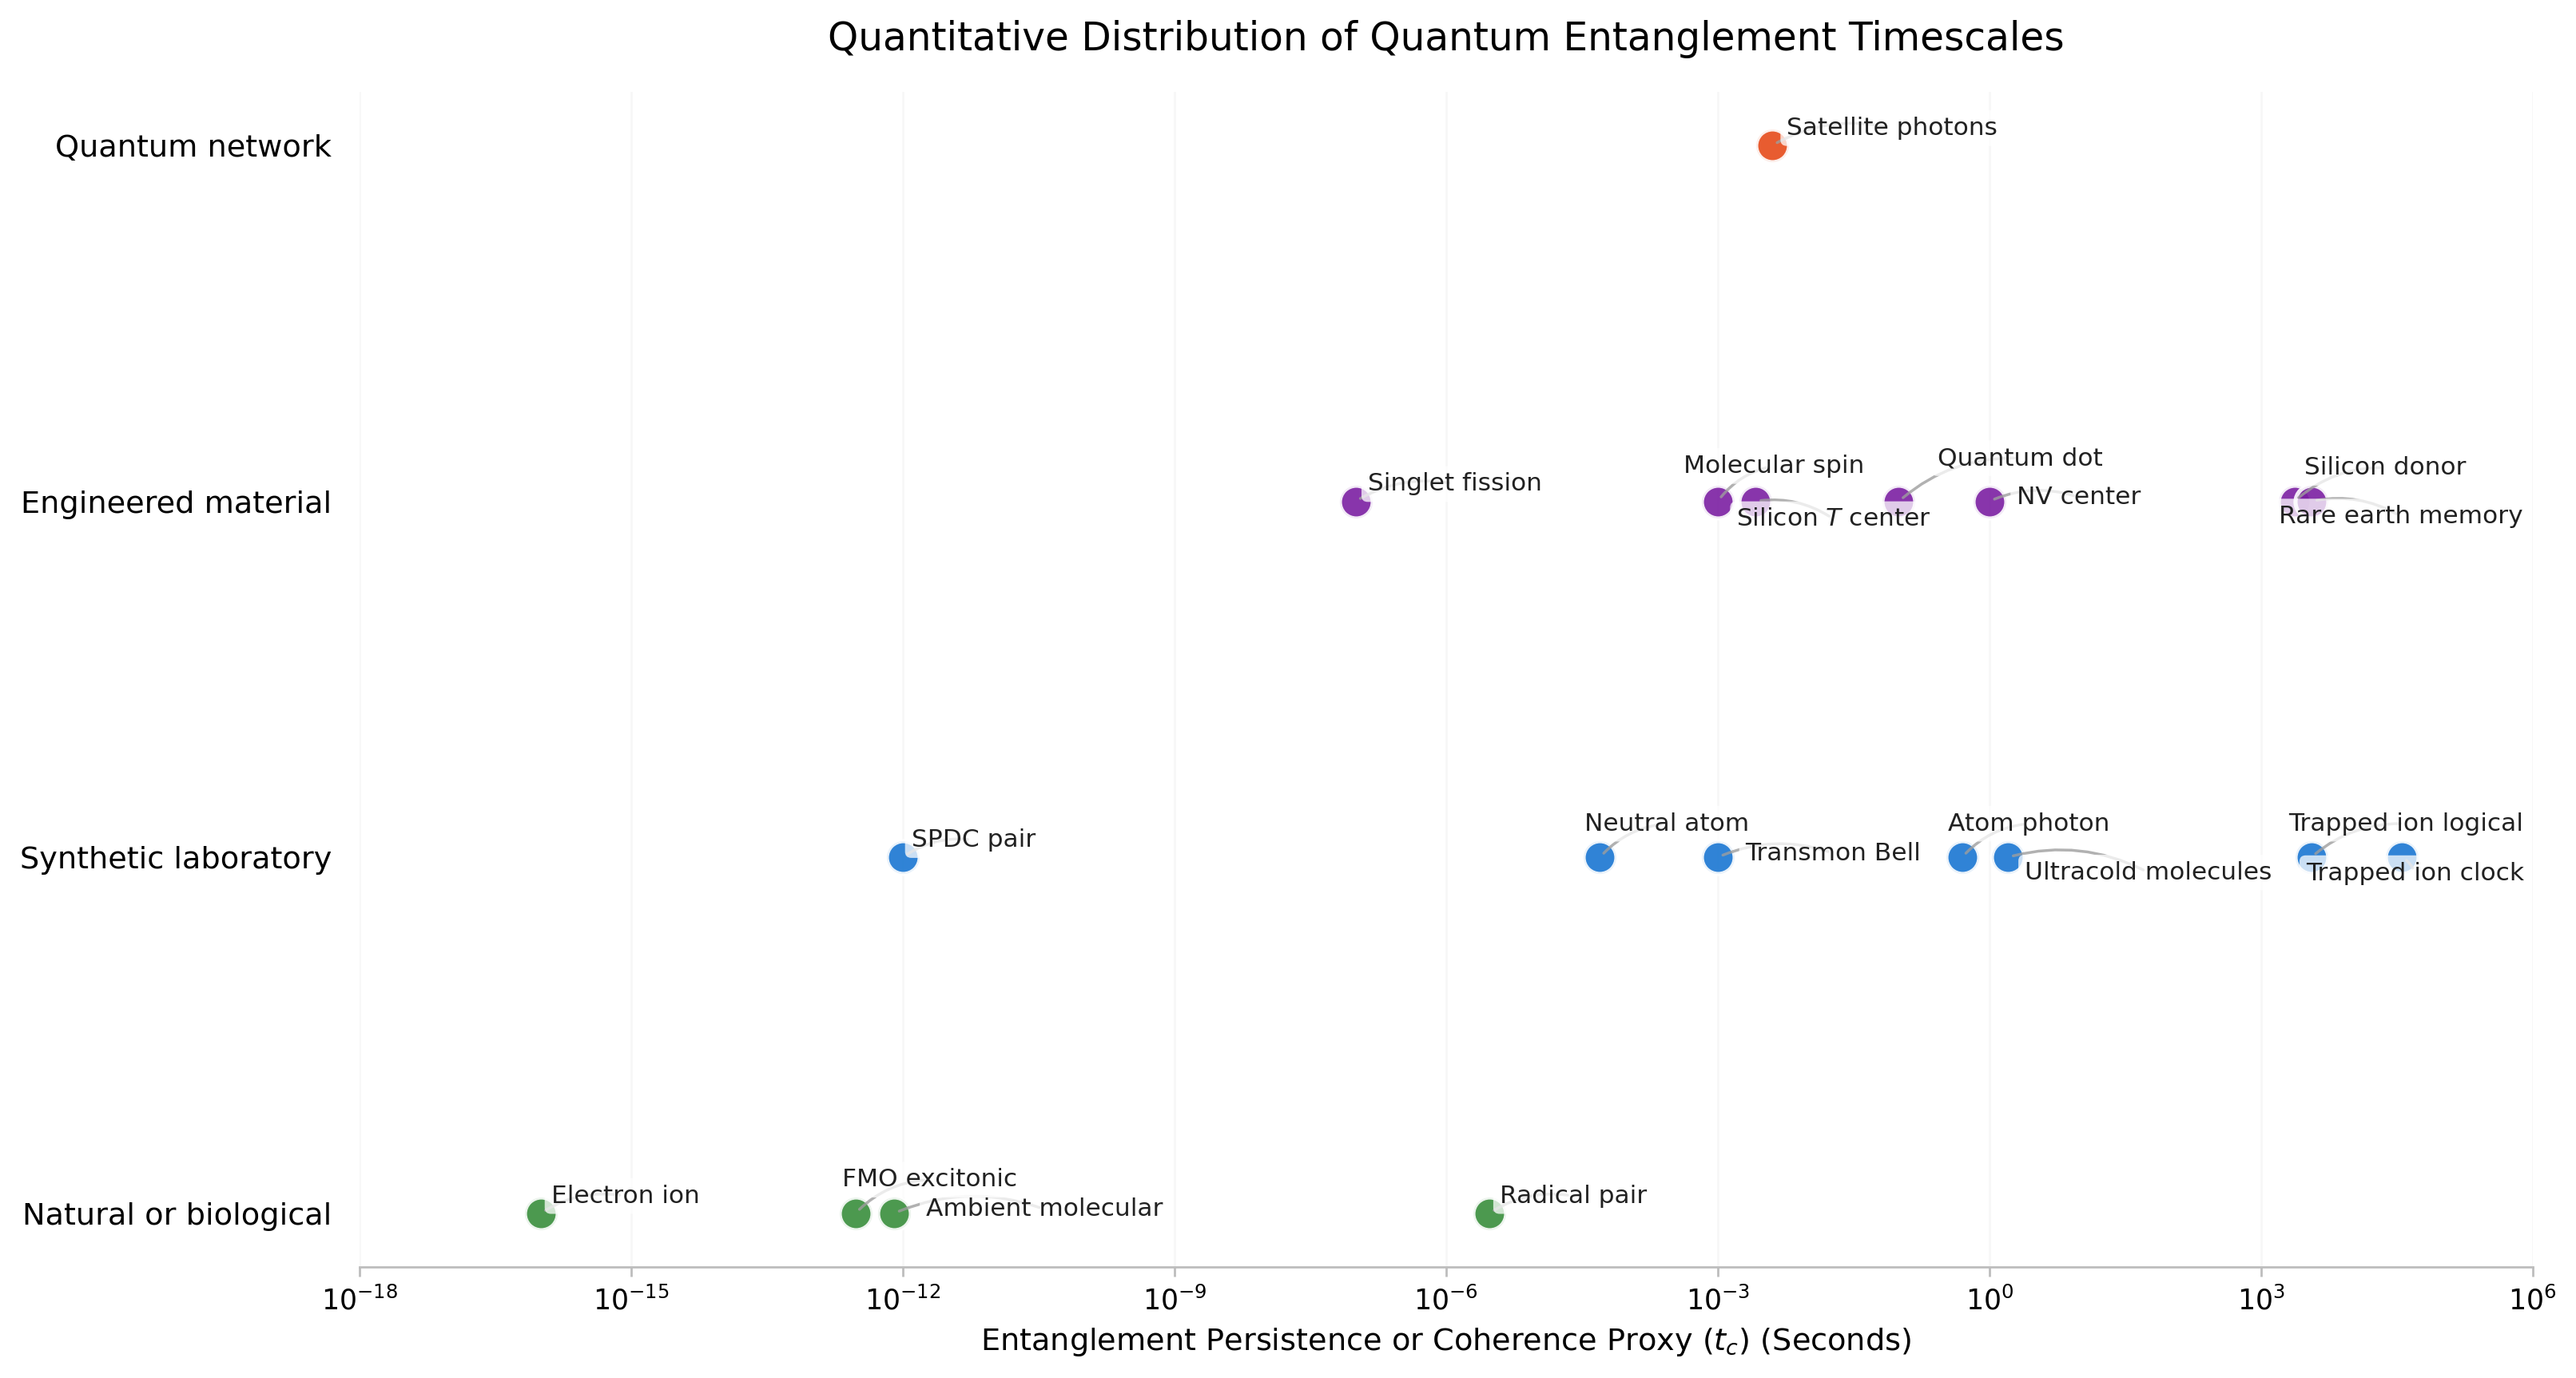

In [ ]:
"""
Generates a quantitative scatter plot of quantum coherence timescales.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dataclasses import dataclass
from typing import Final
from adjustText import adjust_text

# Control Knobs for Graph Configuration
FIGURE_WIDTH: Final[float] = 13.0
FIGURE_HEIGHT: Final[float] = 7.0
RESOLUTION_DPI: Final[int] = 250

MARKER_SIZE: Final[float] = 140.0
MARKER_ALPHA: Final[float] = 0.90
GRID_ALPHA: Final[float] = 0.25

# Control Knobs for Text Repulsion Algorithm
REPULSION_EXPAND_POINTS: Final[tuple[float, float]] = (1.5, 1.8)
REPULSION_EXPAND_TEXT: Final[tuple[float, float]] = (1.2, 1.5)
REPULSION_FORCE_TEXT: Final[tuple[float, float]] = (1.5, 2.5)
REPULSION_FORCE_STATIC: Final[tuple[float, float]] = (1.0, 1.5)

# Establishing the preferred resolution baseline and typography
plt.rcParams.update({
    'figure.dpi': RESOLUTION_DPI,
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
    'font.weight': 'normal',
})

COLOR_PALETTE: Final[dict[str, str]] = {
    "Natural or biological": "#388e3c",
    "Synthetic laboratory": "#1976d2",
    "Engineered material": "#7b1fa2",
    "Quantum network": "#e64a19",
}

@dataclass(frozen=True)
class CoherenceAnchor:
    """Container for a distinct quantitative entanglement record."""
    label: str
    origin: str
    duration_s: float

# Representative subset of the coherence dataset for quantitative display
QUANTITATIVE_ENTRIES: Final[tuple[CoherenceAnchor, ...]] = (
    CoherenceAnchor(r"Electron ion", "Natural or biological", 1e-16),
    CoherenceAnchor(r"FMO excitonic", "Natural or biological", 3e-13),
    CoherenceAnchor(r"Ambient molecular", "Natural or biological", 8e-13),
    CoherenceAnchor(r"SPDC pair", "Synthetic laboratory", 1e-12),
    CoherenceAnchor(r"Singlet fission", "Engineered material", 1e-7),
    CoherenceAnchor(r"Radical pair", "Natural or biological", 3e-6),
    CoherenceAnchor(r"Neutral atom", "Synthetic laboratory", 5e-5),
    CoherenceAnchor(r"Transmon Bell", "Synthetic laboratory", 1e-3),
    CoherenceAnchor(r"Molecular spin", "Engineered material", 1e-3),
    CoherenceAnchor(r"Silicon $T$ center", "Engineered material", 2.6e-3),
    CoherenceAnchor(r"Satellite photons", "Quantum network", 4.0e-3),
    CoherenceAnchor(r"Quantum dot", "Engineered material", 1e-1),
    CoherenceAnchor(r"Atom photon", "Synthetic laboratory", 5e-1),
    CoherenceAnchor(r"NV center", "Engineered material", 1.0),
    CoherenceAnchor(r"Ultracold molecules", "Synthetic laboratory", 1.6),
    CoherenceAnchor(r"Silicon donor", "Engineered material", 2340.0),
    CoherenceAnchor(r"Rare earth memory", "Engineered material", 3600.0),
    CoherenceAnchor(r"Trapped ion logical", "Synthetic laboratory", 3600.0),
    CoherenceAnchor(r"Trapped ion clock", "Synthetic laboratory", 36000.0),
)

def create_publication_plot() -> None:
    """
    Constructs and visually renders the annotated logarithmic coherence chart.
    """
    data_frame = pd.DataFrame([
        {
            "Label": anchor.label,
            "Origin": anchor.origin,
            "Duration_Log10": np.log10(anchor.duration_s)
        }
        for anchor in QUANTITATIVE_ENTRIES
    ])

    unique_origins = list(COLOR_PALETTE.keys())
    data_frame['Origin'] = pd.Categorical(
        data_frame['Origin'],
        categories=unique_origins,
        ordered=True
    )

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))

    annotations = []

    # Render each categorical origin using the linear logarithmic projection
    for origin_name, group_data in data_frame.groupby('Origin', observed=True):
        axes.scatter(
            group_data['Duration_Log10'],
            group_data['Origin'],
            color=COLOR_PALETTE.get(str(origin_name), "#000000"),
            s=MARKER_SIZE,
            alpha=MARKER_ALPHA,
            edgecolors='white',
            linewidths=1.5,
            zorder=3
        )

        # Instantiate raw string typographic labels with a translucent bounding box
        for _, row in group_data.iterrows():
            text_element = axes.text(
                row['Duration_Log10'],
                row['Origin'],
                row['Label'],
                size=9,
                color='#212121',
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.75),
                zorder=4
            )
            annotations.append(text_element)

    # Reconstruct the visual logarithmic axis using mathematical string formatting
    axes.set_xticks(np.arange(-18, 7, 3))
    axes.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: r'$10^{{{}}}$'.format(int(x)))
    )

    axes.set_xlabel(
        r'Entanglement Persistence or Coherence Proxy ($t_c$) (Seconds)',
        size=11
    )
    axes.set_title(
        'Quantitative Distribution of Quantum Entanglement Timescales',
        size=14,
        pad=15
    )

    axes.grid(True, which="major", axis="x", linestyle='solid', color='#e0e0e0', alpha=GRID_ALPHA, zorder=0)
    axes.set_axisbelow(True)

    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)
    axes.spines['left'].set_visible(False)
    axes.spines['bottom'].set_color('#bdbdbd')
    axes.tick_params(axis='y', length=0, pad=10)
    axes.tick_params(axis='x', color='#bdbdbd')

    # Execute heavily calibrated text repulsion utilizing a curved connection style
    adjust_text(
        annotations,
        arrowprops=dict(
            arrowstyle="-",
            color='#9e9e9e',
            lw=1.0,
            alpha=0.8,
            connectionstyle="arc3,rad=0.2"
        ),
        expand_points=REPULSION_EXPAND_POINTS,
        expand_text=REPULSION_EXPAND_TEXT,
        force_text=REPULSION_FORCE_TEXT,
        force_static=REPULSION_FORCE_STATIC,
        ax=axes
    )

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    create_publication_plot()

Quantum entanglement lifetimes scale dramatically from vanishingly small fractions of a second in naturally occurring molecular interactions to multiple consecutive hours when utilizing highly protected synthetic solid state architectures engineered in advanced laboratories.